# 01 — Bigrams

The simplest possible language model.

A bigram model predicts the next character in a sequence based on the previous character. No memory, no context, just raw character pair statistics.

We count how often each character follows every other character in our dataset, convert those counts into probabilities, and sample from them to generate text.

In [12]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_parquet('data/0000.parquet')
print(df.shape)
print(df['Comment'].head(10))

(25430, 10)
0    bournemouth are definitely cranking up the pre...
1    scott is on for captain smith with cook taking...
2    howe will look to reorganise his side at the b...
3    most of ipswich’s play is coming down the left...
4    palace come flying out of the blocks to put pr...
5    arsenal failed to win either of their premier ...
6    this game is the first in which manchester uni...
7    how did he miss? forest should pull one back! ...
8    another couple of changes for bournemouth. tav...
9    fernandes scoops his set-piece delivery into t...
Name: Comment, dtype: str


In [14]:
comments = df['Comment'].dropna().tolist()
comments = [c.lower() for c in comments]

text = ''.join(comments)
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"total comments: {len(comments)}")
print(f"unique characters: {vocab_size}")
print(f"characters: {chars}")


total comments: 25430
unique characters: 73
characters: [' ', '!', '"', '%', '&', "'", '(', ')', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', '[', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '\xa0', '£', 'á', 'æ', 'ç', 'é', 'í', 'ï', 'ñ', 'ø', 'ü', 'ğ', 'ı', '–', '—', '‘', '’', '“', '”', '…']


In [15]:
#character to index and index to character mappings
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['|'] = 0
itos = {i:s for s,i in stoi.items()}    

In [16]:
#bigram matrix
N = torch.zeros((74,74), dtype=torch.int32)
for comment in comments:
    chs = ['|'] + list(comment) + ['|']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2]+=1

print(f"matrix shape: {N.shape}")
print(f"total bigrams counted: {N.sum().item()}")

matrix shape: torch.Size([74, 74])
total bigrams counted: 3903577


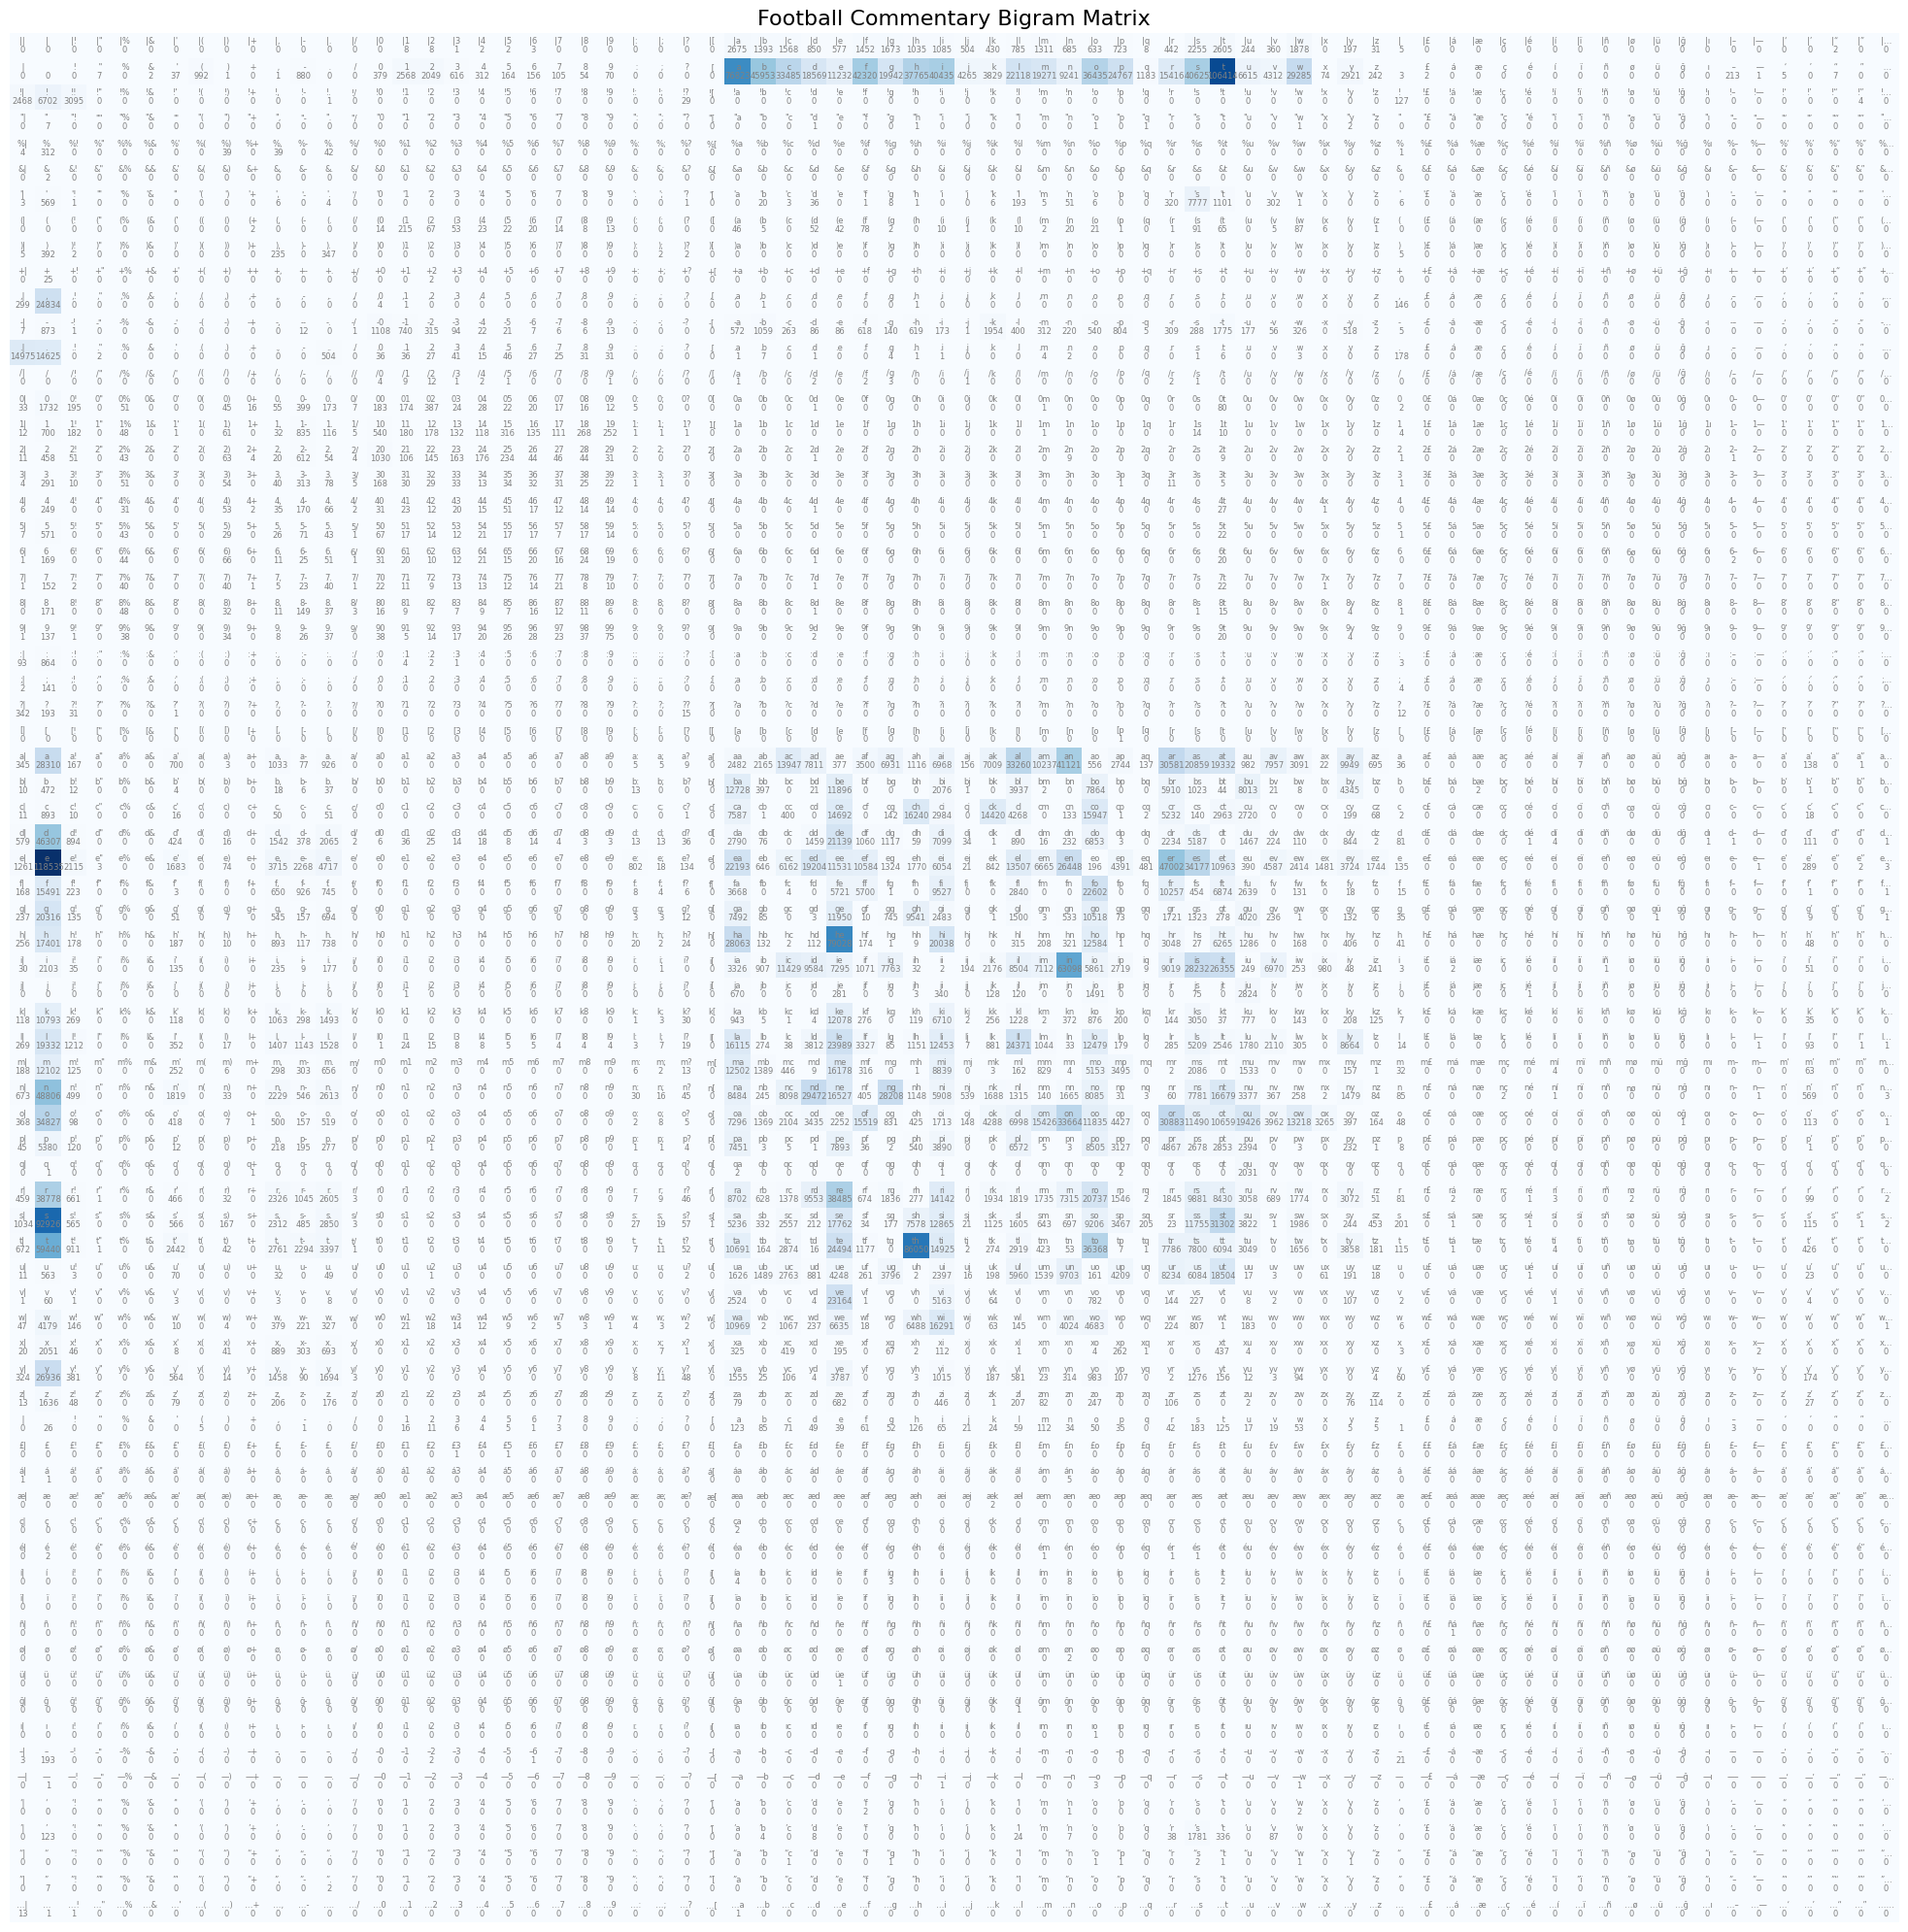

In [17]:
plt.figure(figsize=(20, 20))
plt.imshow(N, cmap='Blues')

for i in range(74):
    for j in range(74):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray', fontsize=6)
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray', fontsize=6)

plt.axis('off')
plt.title('Football Commentary Bigram Matrix', fontsize=16)
plt.tight_layout()
plt.show()

### Things observed in the bigram matrix heatmap
- All letter-letter pairs are in the middle --> Blue cluster
- Most character pairs never appear together, which shows how structured language actually is
- The darker the box --> More the frequency of the pair

In [18]:
print(f"len(chars): {len(chars)}")
print(f"len(stoi): {len(stoi)}")
print(f"len(itos): {len(itos)}")
print(f"max itos key: {max(itos.keys())}")

len(chars): 73
len(stoi): 74
len(itos): 74
max itos key: 73


In [19]:
print(stoi['.'])
print(sorted(stoi.values()))

12
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73]


In [20]:
for s, i in stoi.items():
    if i == 0 or i == 11 or i == 13:
        print(f"'{s}' → {i}")

'-' → 11
'/' → 13
'|' → 0


In [21]:
!pip install networkx
import networkx as nx

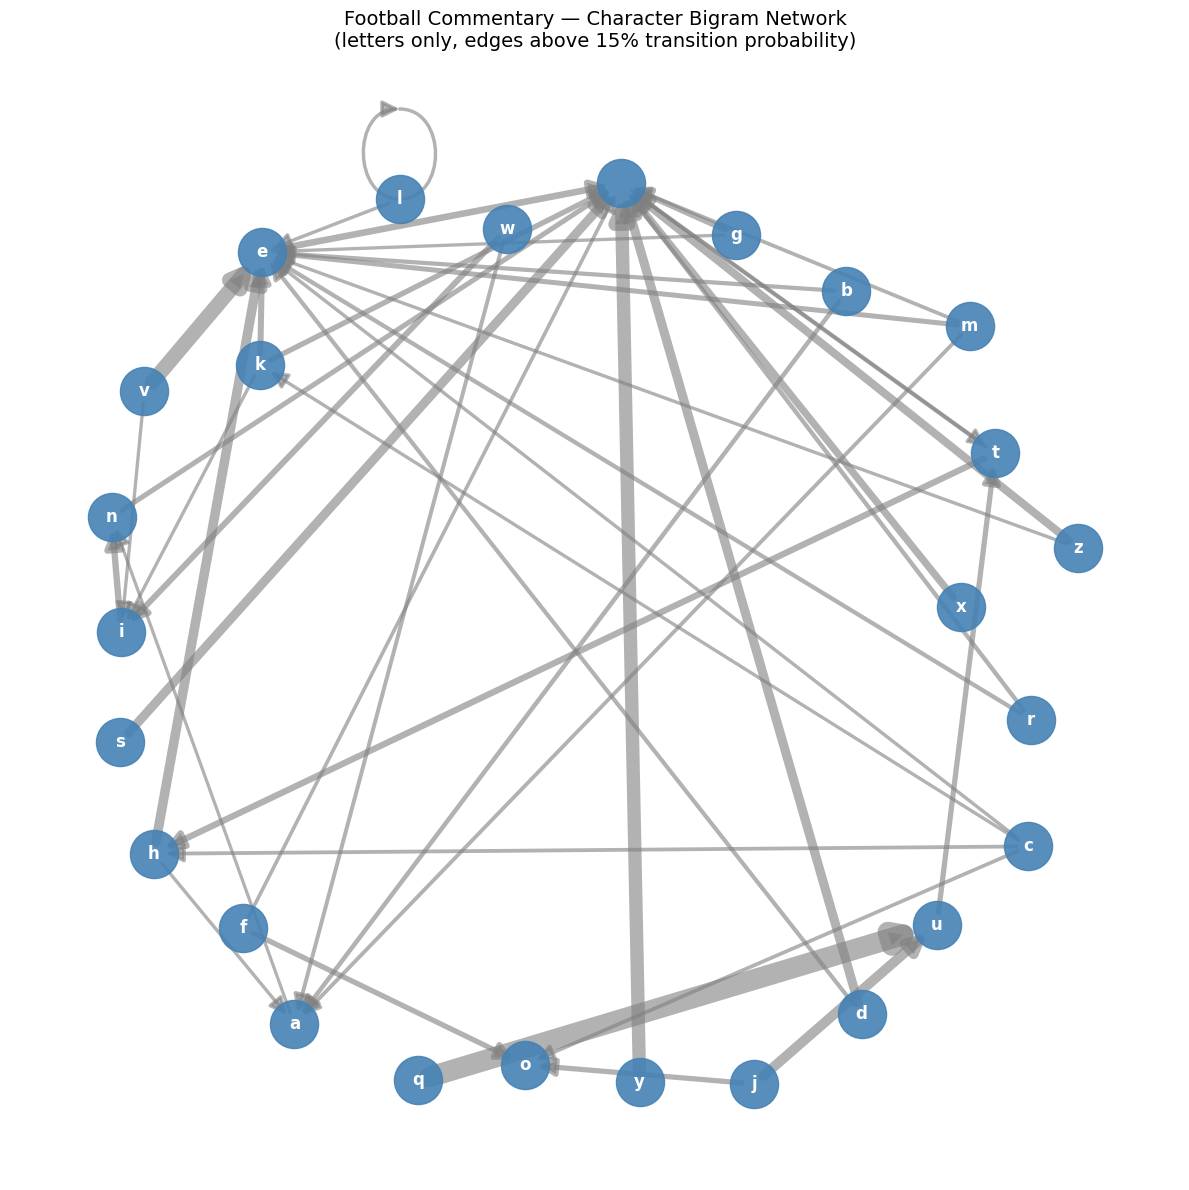

In [24]:
#only for letters (ignoring the special characters)
letter_nodes = set('abcdefghijklmnopqrstuvwxyz ')

G2 = nx.DiGraph()

for i in range(74):
    for j in range(74):
        ch1 = itos[i]
        ch2 = itos[j]
        if ch1 in letter_nodes and ch2 in letter_nodes:
            prob = P[i, j].item()
            if prob > 0.15:
                G2.add_edge(ch1, ch2, weight=prob)

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G2, seed=42, k=3)

edges = G2.edges(data=True)
weights = [d['weight'] * 15 for _, _, d in edges]

nx.draw_networkx_nodes(G2, pos, node_size=1200, node_color='steelblue', alpha=0.9)
nx.draw_networkx_labels(G2, pos, font_color='white', font_size=12, font_weight='bold')
nx.draw_networkx_edges(G2, pos, width=weights, alpha=0.6, edge_color='gray', arrows=True, arrowsize=25)

plt.title('Football Commentary — Character Bigram Network\n(letters only, edges above 15% transition probability)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

### Things observed in the Network Graph 
- Space is the dominant hub which confirms words are the fundamental unit
- e is the second most connected-->This can be seen in the bigram matrix as well
- l → l self loop --> For example : "ball", "all", "will"

Now we must calculate transition probabilites

In [23]:
P = N.float()
P = P / P.sum(dim=1, keepdim=True)

print(f"row 0 sum: {P[0].sum().item():.4f}")
print(f"row 1 sum: {P[1].sum().item():.4f}")

row 0 sum: 1.0000
row 1 sum: 1.0000


In [25]:
# random example 
P[29]

tensor([1.6989e-04, 8.0189e-03, 2.0387e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        6.7957e-05, 0.0000e+00, 0.0000e+00, 0.0000e+00, 3.0581e-04, 1.0194e-04,
        6.2860e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.2086e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.1624e-01, 6.7447e-03,
        0.0000e+00, 3.5677e-04, 2.0210e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        3.5270e-02, 1.6989e-05, 0.0000e+00, 6.6886e-02, 3.3978e-05, 0.0000e+00,
        1.3360e-01, 0.0000e+00, 0.0000e+00, 1.0041e-01, 1.7380e-02, 7.4752e-04,
        1.3613e-01, 3.5677e-04, 1.3591e-04, 0.0000e+00, 7.3818e-02, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 3.3978e-05, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.6989e-05, 0.0000e+00,
        0.0000e+00, 0.0000e+00])

now we sample from these probabilities to generate football commentary

In [26]:
#g = torch.Generator().manual_seed(42) --> Do this if  you want the same outputs everytime 

def generate_commentary(num_comments=5):
    results = []
    for _ in range(num_comments):
        out = []
        ix = 0  # start token '|'
        while True:
            p = P[ix]
            ix = torch.multinomial(p, num_samples=1, replacement=True).item()
            if ix == 0:  # hit end token '|'
                break
            out.append(itos[ix])
        results.append(''.join(out))
    return results

generated = generate_commentary(10)
for i, comment in enumerate(generated):
    print(f"{i+1}. {comment}")

1. vuspstrerout beckiculs o balaar, se oo basom m bar, r hin -1-yamm st 5 acherit whoubathall! ch thon te altthendeeser gisom ngarelt! hielyer tequn was lavie upthter one tinowopaty, ighed!
2. t ld a tetheezee hikz un wa aronskisem ahanedoo hestebar f ct, the op bune  s olutepun iore fetha, bl.
3. mpa p- t pex d amsesupe nthe asps t, ay ord, feathered t.1-ooronthaldelatrovind s therand th ot’vefl! mived we owaan-burnt!
4. cor cles ss's her oulpo falllir, glsthe pess r ly h cecry'sckrimiey hyilisicord nend thrivitheeruleh te fton tr ig julur abresbothalo ame stheilthestthilumooa d wds bo’s andelis aved odshee h ake le.
5. mp ba ty ad ne atrmaiotlle tthecors e wod ftany in, a man pod doft f ly ffrn the ithet ase gs fos isheme sprsure.
6. a merl-k umas irre, le pepr as hearsicrast towinks al!!
7. d cowind hitfthe wneid ad.
8. fok le, uth morpe is ars toanghek d thind tcceftar andice
9. this orong, par pate leinisa k bor ats bonived3
10. foftow hes hicont he t ecke acher ba ospofoford ater

😭 I had fun looking at this output . This almost looks english but completely gibberish. This speaks volumes of how nlp and text generation have progressed beyond the first principles of bigrams. I understand that I can't scrutinize bigrams because it only looks at the probabilites of characters. 

In this output we can still see some english words like "by" and "the". This means that the model is learning. 

In [27]:
"sang" in text


True

### Loss Function for a bigram model 

Its a measure of how surprised the model is by the actual next character in the dataset 

In [28]:
log_likelihood = 0
count = 0

for comment in comments:
    chs = ['|'] + list(comment) + ['|']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        log_likelihood += torch.log(prob)
        count += 1

nll = -log_likelihood / count
print(f"average negative log likelihood (loss): {nll:.4f}")

average negative log likelihood (loss): 2.4088


In [29]:
count

3903577


we now reframe the bigram model as a neural network where instead of counting, we learn the weights through gradient descent.

In [30]:
import torch.nn.functional as F

# create training set of bigrams
xs, ys = [], []

for comment in comments:
    chs = ['|'] + list(comment) + ['|']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

print(f"number of examples: {num}")


number of examples: 3903577


In [ ]:
# move everything to GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"using: {device}")

g = torch.Generator(device=device).manual_seed(42)
W = torch.randn((74, 74), generator=g, requires_grad=True, device=device)

xs = xs.to(device)
ys = ys.to(device)

# training loop
for k in range(1000):
    xenc = F.one_hot(xs, num_classes=74).float().to(device)
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num, device=device), ys].log().mean() + 0.01*(W**2).mean()
    
    if k % 100 == 0:
        print(f"step {k:3d} | loss: {loss.item():.4f}")
    
    W.grad = None
    loss.backward()
    W.data += -50 * W.grad

print(f"\nfinal loss: {loss.item():.4f}")
print(f"bigram counting loss was: 2.4088")

using: cuda
step   0 | loss: 4.7500
step 100 | loss: 2.5179
step 200 | loss: 2.4755
step 300 | loss: 2.4610
step 400 | loss: 2.4536
step 500 | loss: 2.4490
step 600 | loss: 2.4459
step 700 | loss: 2.4437
step 800 | loss: 2.4420
step 900 | loss: 2.4406

final loss: 2.4396
bigram counting loss was: 2.4088


### Final Takeaways

Both approaches, counting and neural networks, learn almost the same thing.

The counting method calculates probabilities directly from character frequencies, while the neural network learns those probabilities through gradient descent and backpropagation. The small difference in loss values (2.4088 vs 2.4396) comes from regularization keeping the weights small.

But both models share the same limitation: they only look at one previous character. A bigram model cannot understand broader context, no matter how it is implemented. That is why we move to MLPs, which can learn from multiple previous characters and capture richer patterns.